# Seaborn: Data Visualization

Seaborn is a Python library built on Matplotlib that helps create clear and attractive statistical visualizations. This notebook covers distribution, categorical, relationship, and correlation plots using the dataset columns `InternetUsers`, `BirthRate`, and `IncomeGroup`.

## 1. Import Libraries

Import Pandas for working with tabular data, Seaborn for statistical plots, and Matplotlib for labels and layout.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Dataset

Keep `data_used.xlsx` in the same folder as this notebook, or update `file_path` to the correct location on your computer.

In [2]:
file_path = "data_used.xlsx"
df = pd.read_excel(file_path)

# Preview the first five rows
df.head()

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income


## 3. Explore the Data

Check the dataset dimensions, column names, data types, and missing values before plotting.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (195, 5)

Column names:
['CountryName', 'CountryCode', 'BirthRate', 'InternetUsers', 'IncomeGroup']

Data types:
CountryName          str
CountryCode          str
BirthRate        float64
InternetUsers    float64
IncomeGroup          str
dtype: object

Missing values per column:
CountryName      0
CountryCode      0
BirthRate        0
InternetUsers    0
IncomeGroup      0
dtype: int64


In [4]:
df.describe(include="all")

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
count,195,195,195.000000,195.000000,195
unique,195,195,NaN,NaN,4
top,Aruba,ABW,NaN,NaN,High income
freq,1,1,NaN,NaN,67
mean,NaN,NaN,21.469928,42.076471,NaN
std,NaN,NaN,10.605467,29.030788,NaN
min,NaN,NaN,7.900000,0.900000,NaN
25%,NaN,NaN,12.120500,14.520000,NaN
50%,NaN,NaN,19.680000,41.000000,NaN
75%,NaN,NaN,29.759500,66.225000,NaN


## 4. Univariate Analysis

Univariate analysis studies one variable at a time. A histogram shows the distribution of a numeric variable, while the KDE curve gives a smoothed view of its shape.

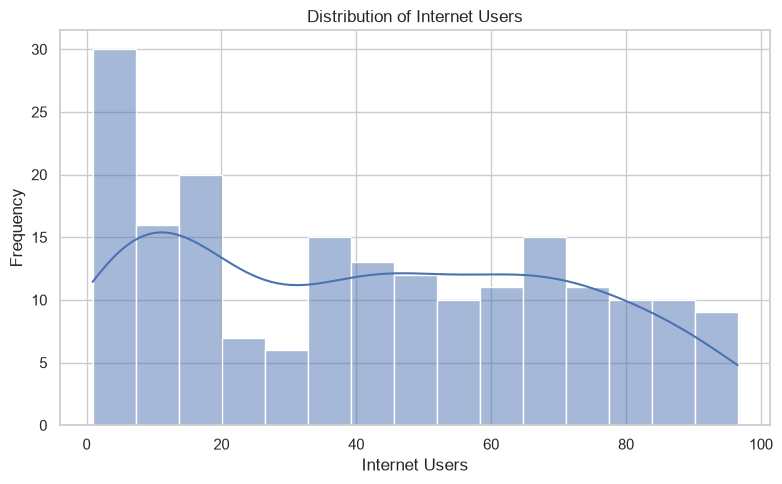

In [5]:
sns.histplot(data=df, x="InternetUsers", bins=15, kde=True)
plt.title("Distribution of Internet Users")
plt.xlabel("Internet Users")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Count Plot

A count plot displays how many observations belong to each category. It is useful for comparing the number of records in each income group.

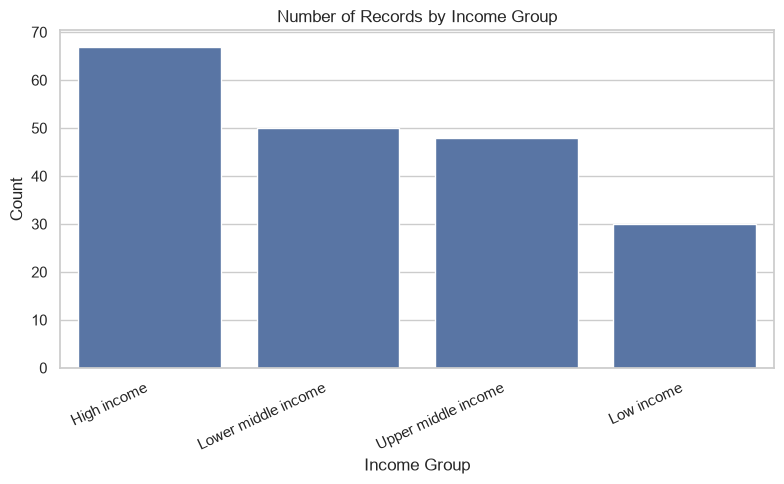

In [6]:
sns.countplot(data=df, x="IncomeGroup", order=df["IncomeGroup"].value_counts().index)
plt.title("Number of Records by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

Bivariate analysis explores the relationship between two variables. A scatter plot helps reveal trends, clusters, and possible outliers in the relationship between internet use and birth rate.

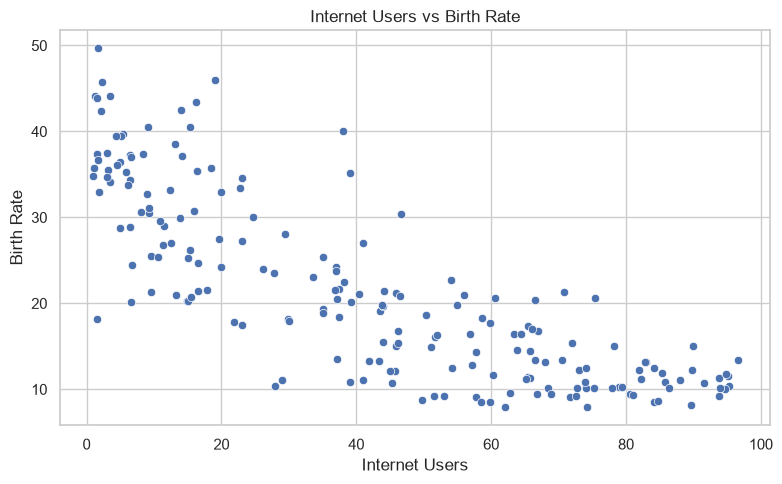

In [7]:
sns.scatterplot(data=df, x="InternetUsers", y="BirthRate")
plt.title("Internet Users vs Birth Rate")
plt.xlabel("Internet Users")
plt.ylabel("Birth Rate")
plt.tight_layout()
plt.show()

### Scatter Plot with a Trend Line

The regression line summarizes the overall linear trend. It shows an association in the data, not proof that one variable causes the other.

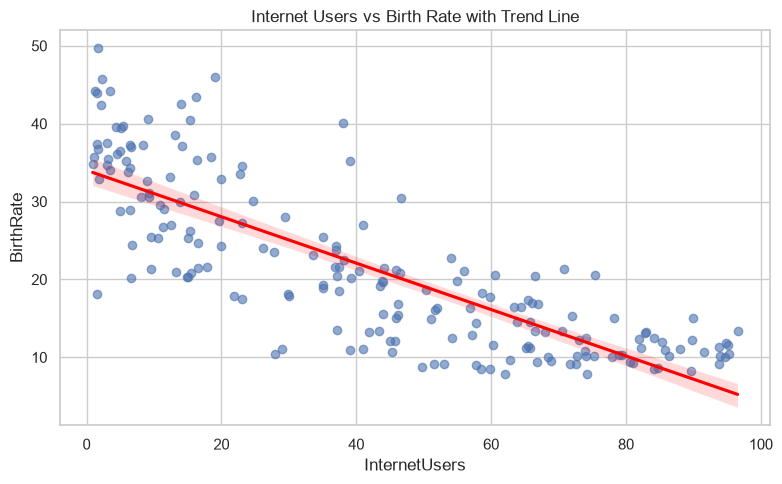

In [8]:
sns.regplot(data=df, x="InternetUsers", y="BirthRate",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Internet Users vs Birth Rate with Trend Line")
plt.tight_layout()
plt.show()

## 6. Multivariate Analysis

Multivariate analysis considers more than two variables. Using `hue="IncomeGroup"` adds a color grouping to the scatter plot, making it easier to compare groups.

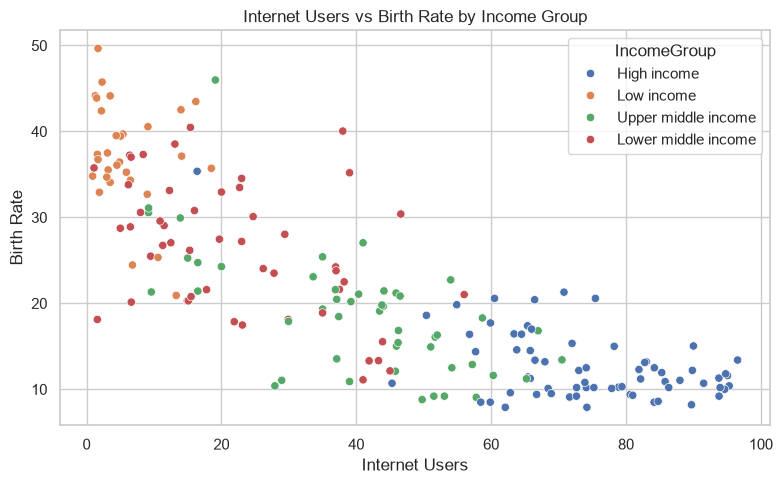

In [9]:
sns.scatterplot(data=df, x="InternetUsers", y="BirthRate", hue="IncomeGroup")
plt.title("Internet Users vs Birth Rate by Income Group")
plt.xlabel("Internet Users")
plt.ylabel("Birth Rate")
plt.tight_layout()
plt.show()

## 7. Box Plot and Outliers

A box plot compares the distribution of a numeric variable across categories. Points beyond the whiskers may be potential outliers, but they should be investigated rather than automatically removed.

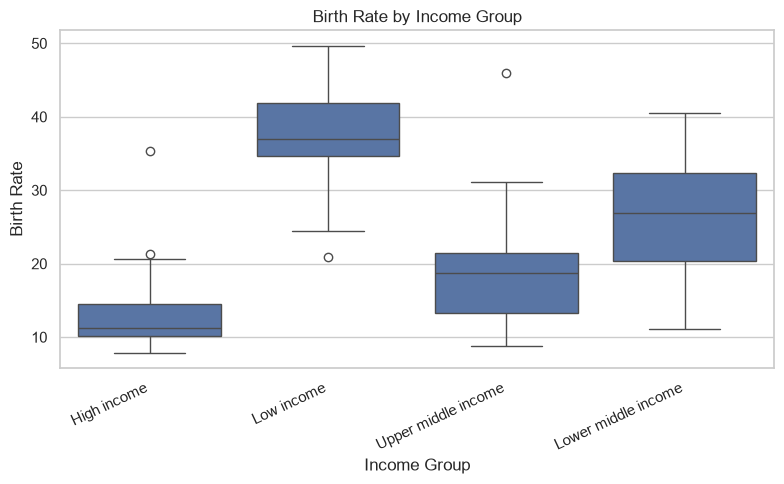

In [10]:
sns.boxplot(data=df, x="IncomeGroup", y="BirthRate")
plt.title("Birth Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Birth Rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 8. Violin Plot

A violin plot combines a box-plot-like summary with a density shape. It can help compare both the spread and shape of birth-rate distributions across income groups.

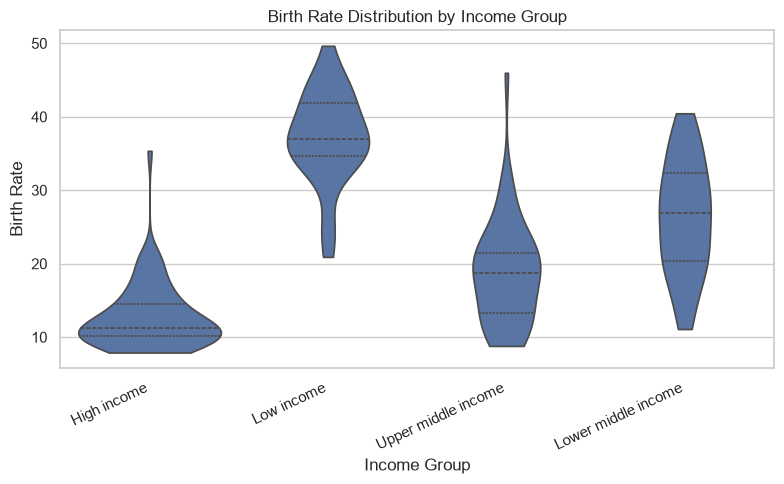

In [11]:
sns.violinplot(data=df, x="IncomeGroup", y="BirthRate", inner="quartile", cut=0)
plt.title("Birth Rate Distribution by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Birth Rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 9. Bar Plot

A bar plot can compare a summary statistic across categories. Here, each bar shows the mean birth rate for an income group; the error bars show uncertainty around the estimate.

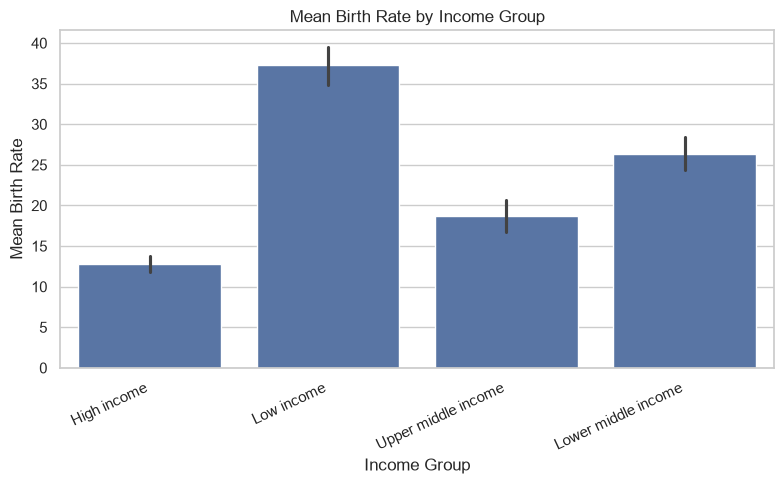

In [12]:
sns.barplot(data=df, x="IncomeGroup", y="BirthRate", errorbar=("ci", 95))
plt.title("Mean Birth Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Mean Birth Rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

A correlation heatmap visualizes pairwise correlations among numeric columns. Values closer to `1` indicate positive linear association, values closer to `-1` indicate negative linear association, and values near `0` indicate weak linear association.

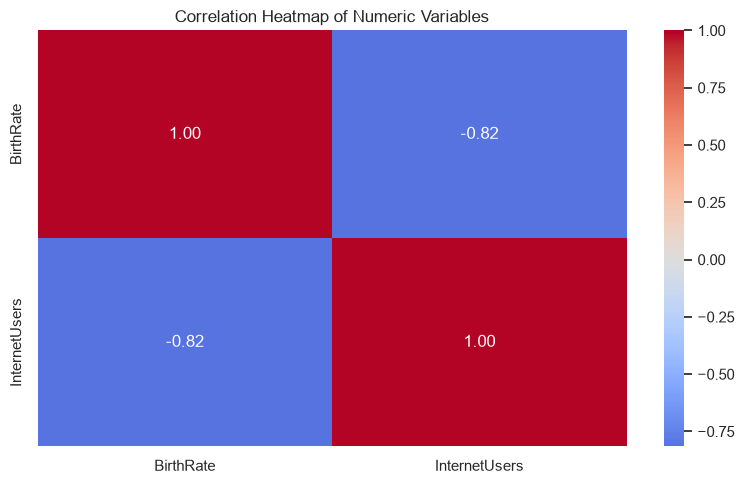

In [13]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

## 11. Pair Plot

A pair plot displays pairwise relationships between selected numeric variables and their individual distributions. It can be useful for spotting broad patterns across several variables at once.

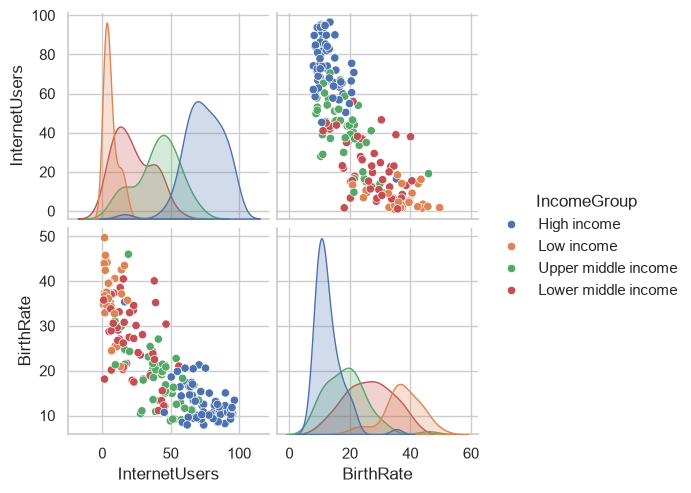

In [14]:
pair_columns = [col for col in ["InternetUsers", "BirthRate"] if col in df.columns]
if len(pair_columns) >= 2:
    sns.pairplot(df, vars=pair_columns, hue="IncomeGroup" if "IncomeGroup" in df.columns else None)
    plt.show()
else:
    print("Pair plot skipped: at least two selected numeric columns are required.")

## 12. Key Takeaways

- Use **histograms** to inspect the distribution of a numeric variable.
- Use **count plots** to compare category frequencies.
- Use **scatter plots and regression plots** to explore relationships between numeric variables.
- Use **box plots and violin plots** to compare distributions across groups and flag potential outliers.
- Use **heatmaps and pair plots** to inspect relationships among multiple numeric variables.

**Tip:** Choose a plot based on the question you want to answer, and label axes and titles so the visualization is easy to understand.

---

# Additional Seaborn Topics

The sections below add commonly used Seaborn plots that were missing from the original notebook. They use a small practice dataset, so these examples run without the separate Excel file.

## 1. Create a Practice Dataset

This illustrative dataset contains numeric values and categories for practicing different plot types.

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

practice_df = pd.DataFrame({
    "StudyHours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7],
    "Score": [42, 48, 51, 55, 59, 62, 67, 70, 74, 78, 84, 91],
    "Department": ["A", "B", "A", "C", "B", "A", "C", "B", "A", "C", "B", "A"],
    "Attendance": [60, 65, 70, 72, 75, 78, 80, 82, 85, 88, 92, 96],
    "ProjectScore": [45, 50, 53, 58, 61, 65, 68, 73, 76, 80, 86, 94]
})
practice_df

,StudyHours,Score,Department,Attendance,ProjectScore
0,1,42,A,60,45
1,2,48,B,65,50
2,2,51,A,70,53
3,3,55,C,72,58
4,3,59,B,75,61
5,4,62,A,78,65
6,4,67,C,80,68
7,5,70,B,82,73
8,5,74,A,85,76
9,6,78,C,88,80


## 2. KDE Plot

A KDE plot shows a smoothed estimate of a numeric variable's distribution. It is useful for seeing where values are more concentrated.

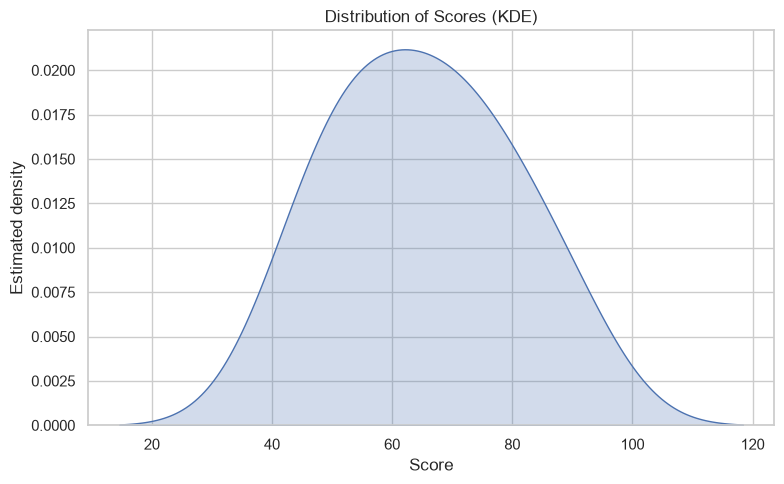

In [16]:
sns.kdeplot(data=practice_df, x="Score", fill=True)
plt.title("Distribution of Scores (KDE)")
plt.xlabel("Score")
plt.ylabel("Estimated density")
plt.tight_layout()
plt.show()

## 3. ECDF Plot

An ECDF plot shows the proportion of observations at or below each value. It helps interpret cumulative percentages and approximate percentiles.

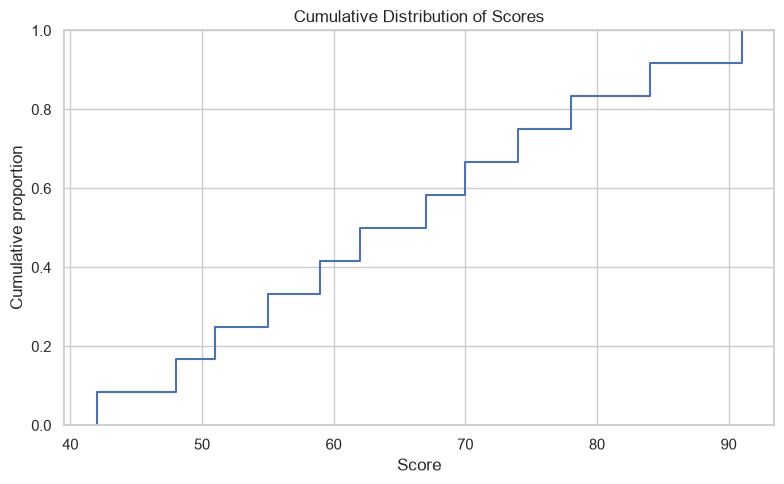

In [17]:
sns.ecdfplot(data=practice_df, x="Score")
plt.title("Cumulative Distribution of Scores")
plt.xlabel("Score")
plt.ylabel("Cumulative proportion")
plt.tight_layout()
plt.show()

## 4. Strip Plot

A strip plot shows each data point across categories. Jitter spreads points slightly so overlapping observations are easier to see.

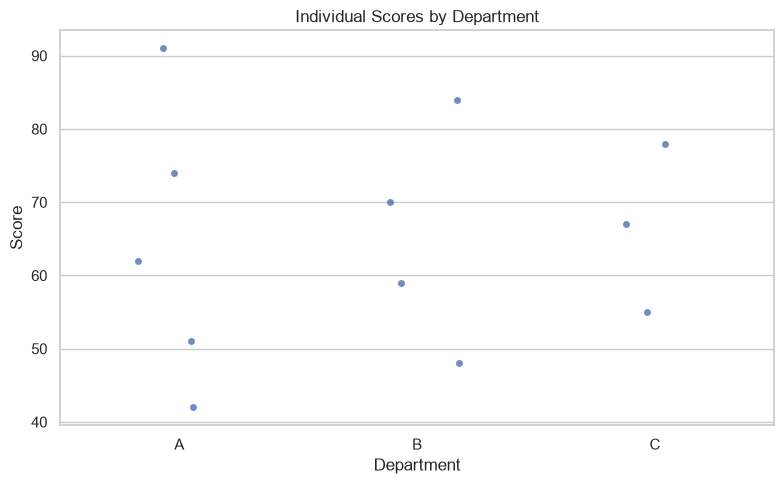

In [18]:
sns.stripplot(data=practice_df, x="Department", y="Score", jitter=0.18, alpha=0.8)
plt.title("Individual Scores by Department")
plt.xlabel("Department")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 5. Swarm Plot

A swarm plot positions individual points to reduce overlap. It is helpful for smaller datasets, but can become crowded with many observations.

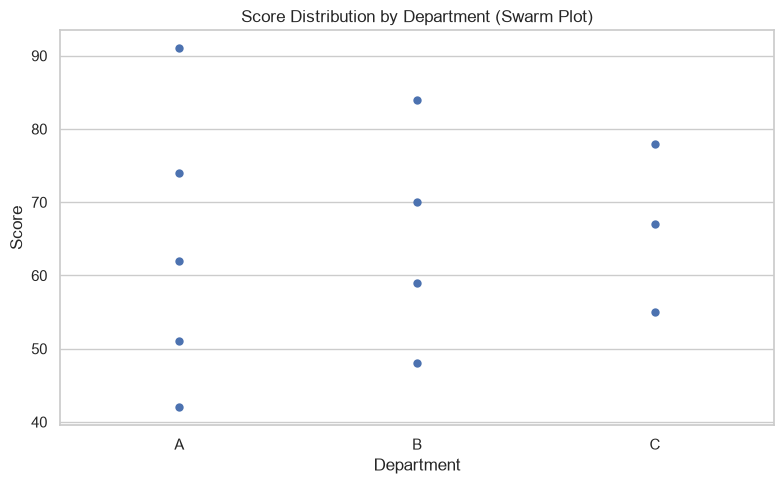

In [19]:
sns.swarmplot(data=practice_df, x="Department", y="Score", size=6)
plt.title("Score Distribution by Department (Swarm Plot)")
plt.xlabel("Department")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 6. Line Plot

A line plot connects values in an ordered sequence. Here, study hours are the x-axis, so the chart shows how scores vary with study time in this example dataset.

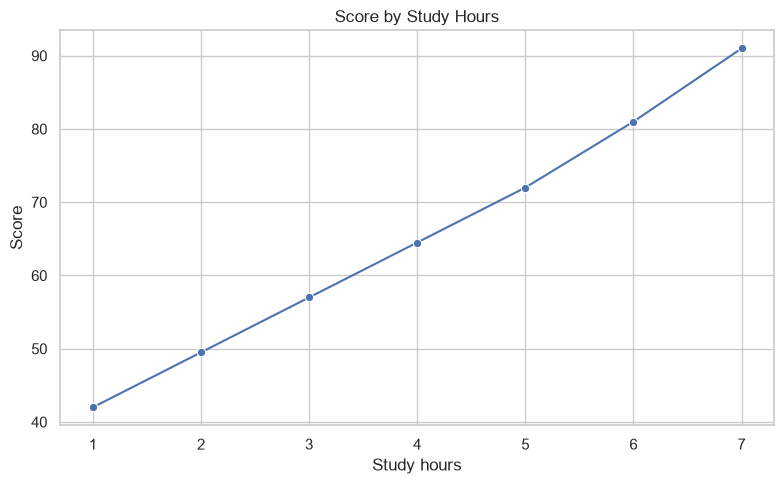

In [20]:
line_df = practice_df.sort_values("StudyHours")
sns.lineplot(data=line_df, x="StudyHours", y="Score", marker="o", errorbar=None)
plt.title("Score by Study Hours")
plt.xlabel("Study hours")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 7. Residual Plot

A residual plot compares model errors with the predictor. A visible pattern may indicate that a simple linear model does not capture the relationship well.

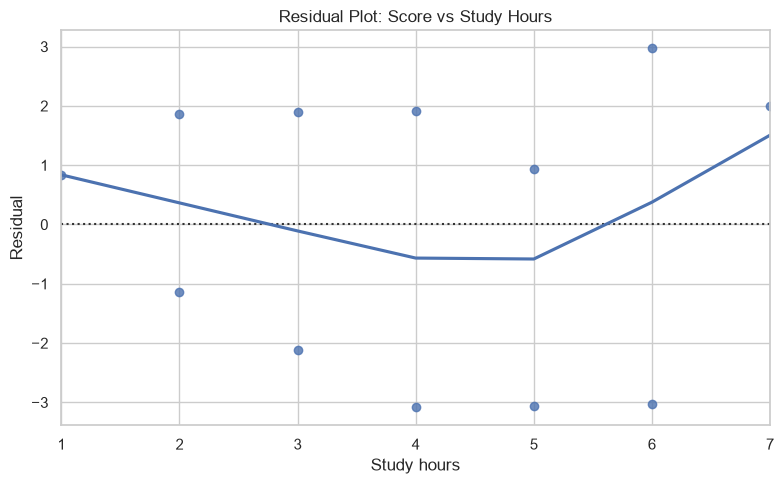

In [21]:
sns.residplot(data=practice_df, x="StudyHours", y="Score", lowess=True)
plt.title("Residual Plot: Score vs Study Hours")
plt.xlabel("Study hours")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 8. Joint Plot

A joint plot combines a relationship plot with the distributions of both variables along the edges. It helps examine two variables together.

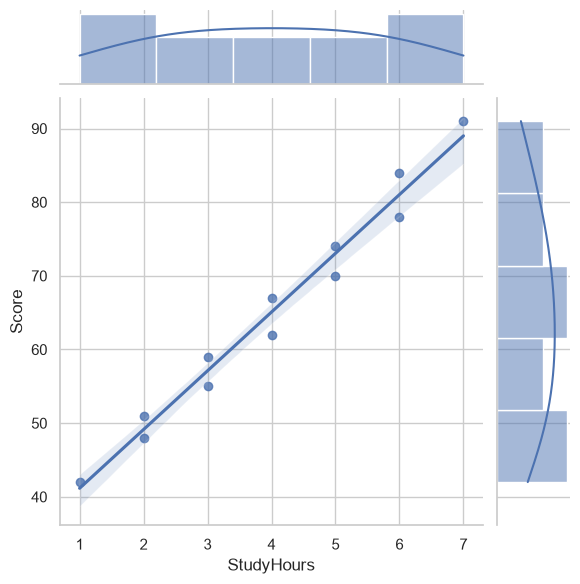

In [22]:
sns.jointplot(data=practice_df, x="StudyHours", y="Score", kind="reg", height=6)
plt.show()

## 9. Pair Plot

A pair plot displays pairwise relationships between several numeric columns. Use only a few columns to keep the figure readable.

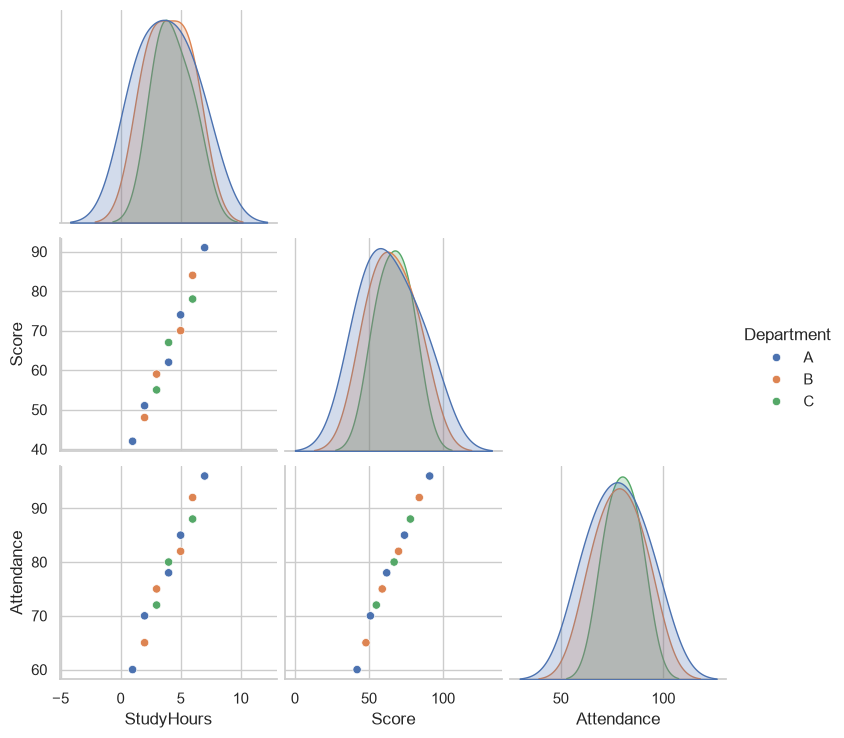

In [23]:
sns.pairplot(practice_df, vars=["StudyHours", "Score", "Attendance"], hue="Department", corner=True)
plt.show()

## 10. Figure-Level `relplot()`

`relplot()` makes it easy to split a relationship plot into separate panels. Facets can make group differences easier to compare.

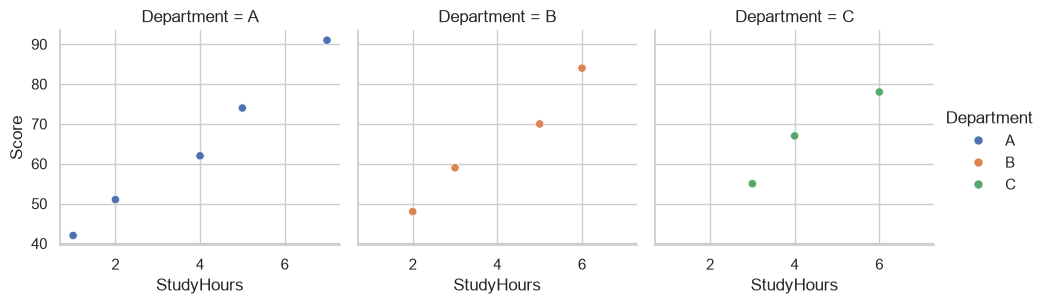

In [24]:
sns.relplot(data=practice_df, x="StudyHours", y="Score", hue="Department",
            col="Department", kind="scatter", height=3.2)
plt.show()

## 11. Figure-Level `catplot()`

`catplot()` is a flexible interface for categorical charts. The `kind` argument can be changed to values such as `box`, `violin`, `bar`, or `strip`.

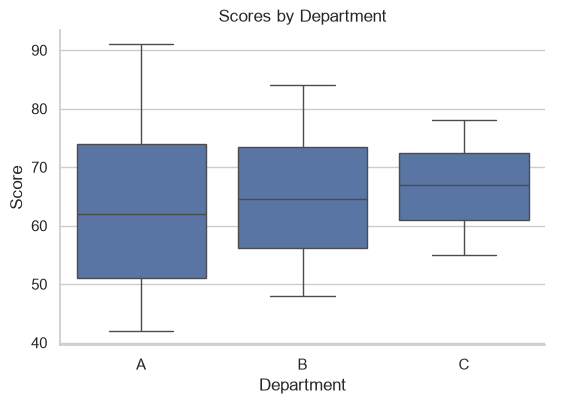

In [25]:
sns.catplot(data=practice_df, x="Department", y="Score", kind="box", height=4, aspect=1.4)
plt.title("Scores by Department")
plt.show()

## 12. Figure-Level `displot()`

`displot()` is designed for distributions and can compare groups using `hue`. It is a figure-level alternative to axes-level distribution functions.

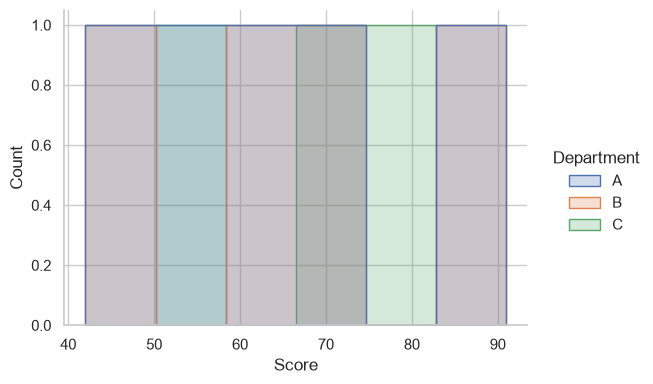

In [26]:
sns.displot(data=practice_df, x="Score", hue="Department", kind="hist",
            bins=6, element="step", height=4, aspect=1.4)
plt.show()

## 13. Correlation Heatmap

A heatmap uses color to represent values in a matrix. Correlations near `1` indicate positive linear association, near `-1` negative linear association, and near `0` weak linear association.

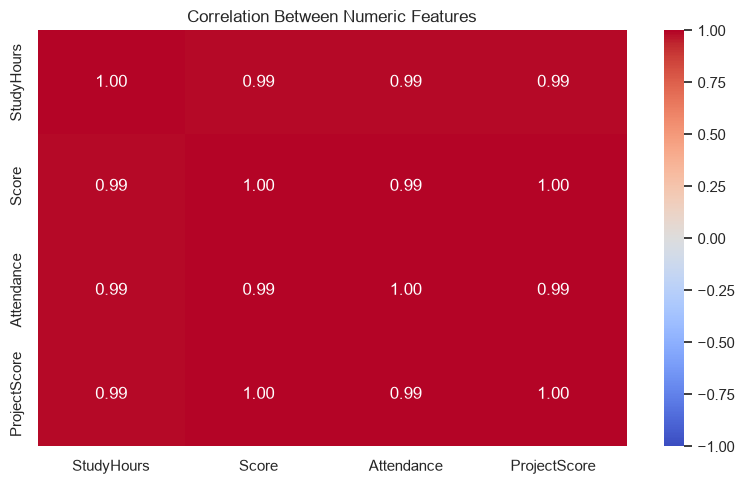

In [27]:
numeric_data = practice_df.select_dtypes(include="number")
corr = numeric_data.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

## 14. Clustermap

A clustermap groups similar rows and columns based on their numeric patterns. Standardizing columns helps compare variables that use different scales.

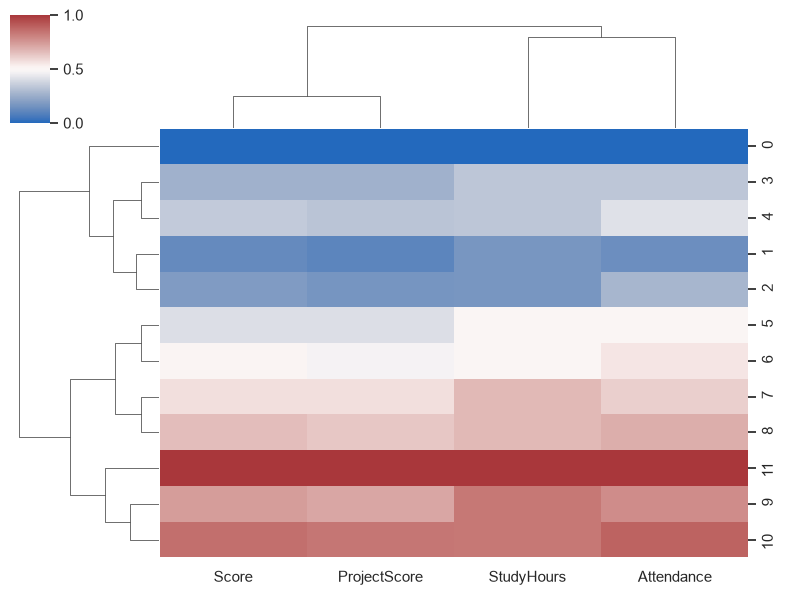

In [28]:
cluster_data = practice_df[["StudyHours", "Score", "Attendance", "ProjectScore"]]
sns.clustermap(cluster_data, standard_scale=1, cmap="vlag", figsize=(8, 6))
plt.show()

## 15. Styling with `hue`, `style`, and a Color Palette

Use color and marker shape to distinguish groups. Consistent labels and a clear legend help viewers interpret the chart.

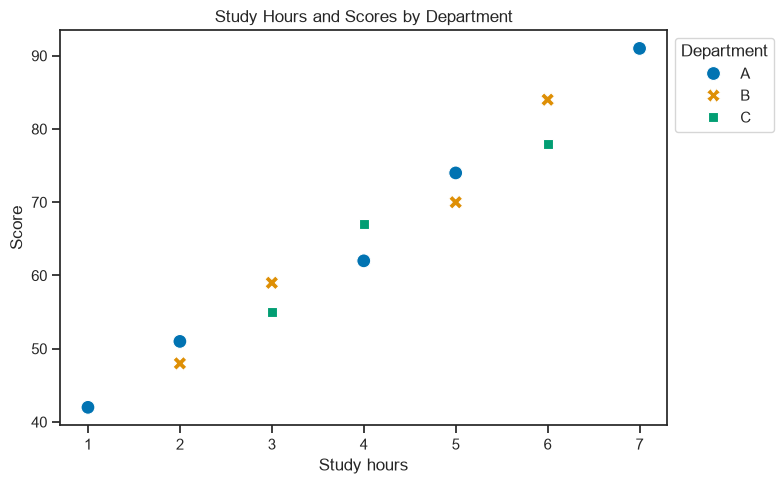

In [29]:
sns.set_theme(style="ticks", palette="colorblind")
ax = sns.scatterplot(data=practice_df, x="StudyHours", y="Score",
                     hue="Department", style="Department", s=100)
ax.set_title("Study Hours and Scores by Department")
ax.set_xlabel("Study hours")
ax.set_ylabel("Score")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")

## 16. Quick Plot Selection Guide

| What you want to understand | Useful functions |
|---|---|
| Numeric distribution | `histplot()`, `kdeplot()`, `ecdfplot()` |
| Number of items in each category | `countplot()` |
| Compare values across groups | `barplot()`, `boxplot()`, `violinplot()` |
| Show individual points in groups | `stripplot()`, `swarmplot()` |
| Relationship between numeric variables | `scatterplot()`, `lineplot()` |
| Add a fitted trend line | `regplot()`, `lmplot()` |
| Compare multiple panels | `relplot()`, `catplot()`, `displot()` |
| Pairwise relationships | `pairplot()`, `jointplot()` |
| Correlation matrix | `heatmap()` |
| Cluster rows and columns | `clustermap()` |
| Inspect regression errors | `residplot()` |

**Practice tip:** For each visualization, write one sentence describing what it shows. Remember that correlation and regression lines show association, not proof of causation.